In [56]:
import wfdb
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [57]:
# load record 100 - one of the MIT-BIH recordings
# each record has a .dat (signal) and .hea (header) file

data_dir = 'data/mit-bih-arrhythmia-database-1.0.0'
record = wfdb.rdrecord(f'{data_dir}/100')

print('Patient record:', record.record_name)
print('Sampling frequency:', record.fs, 'Hz')
print('Signal length:', record.sig_len, 'samples')
print('Duration:', record.sig_len / record.fs, 'seconds')
print('Channels:', record.sig_name)

Patient record: 100
Sampling frequency: 360 Hz
Signal length: 650000 samples
Duration: 1805.5555555555557 seconds
Channels: ['MLII', 'V5']


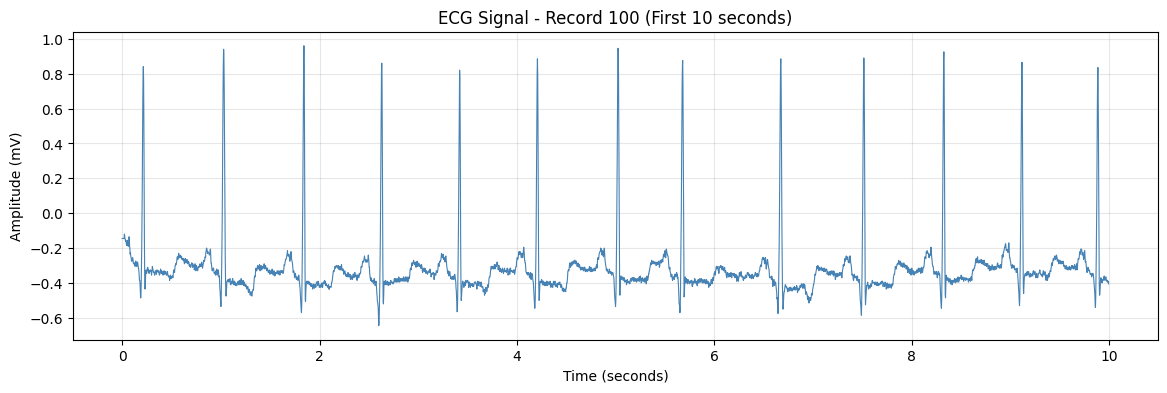

In [58]:
# plot first 10 seconds of the ECG
fs = record.fs # sampling frequency (360Hz)
seconds = 10
samples = seconds * fs

signal = record.p_signal[:samples, 0] # channel 0
time = np.arange(samples) / fs # convert samples to seconds

plt.figure(figsize=(14, 4))
plt.plot(time, signal, color='steelblue', linewidth=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('ECG Signal - Record 100 (First 10 seconds)')
plt.grid(True, alpha=0.3)
plt.show()

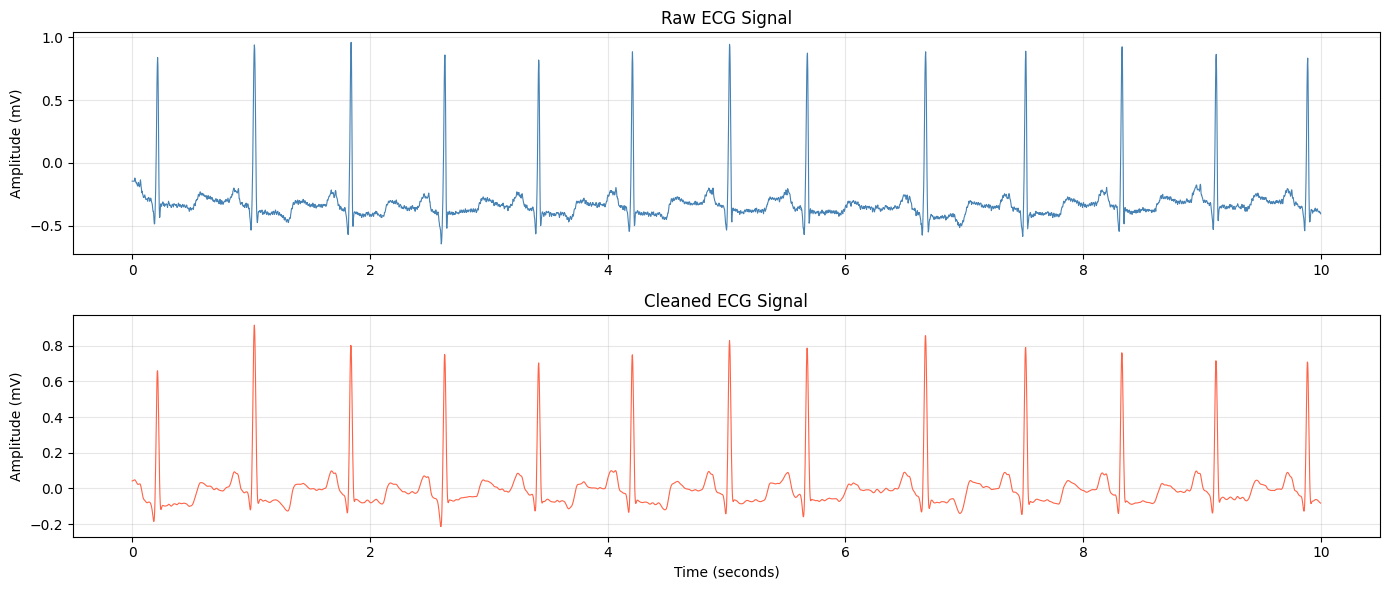

In [59]:
# load the full signal
signal = record.p_signal[:, 0] # use channel 0 (MLII)

# cleaning the ECG signal using neurokit2
# this applies bandpass filter keeping only frequencies
# between 0.5 and 40 Hz where heartbeat information lives
# it also removes baseline wander caused by breathing and movement
signal_clean = nk.ecg_clean(signal, sampling_rate=fs)

# plot raw vs cleaned signal for comparison
seconds = 10
samples = seconds * fs
time = np.arange(samples) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(time, signal[:samples], color='steelblue', linewidth=0.8)
axes[0].set_title('Raw ECG Signal')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, signal_clean[:samples], color='tomato', linewidth=0.8)
axes[1].set_title('Cleaned ECG Signal')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Total R peaks detected: 2270
Recording duration: 30.1 minutes
Average heart rate: 75.4 BPM


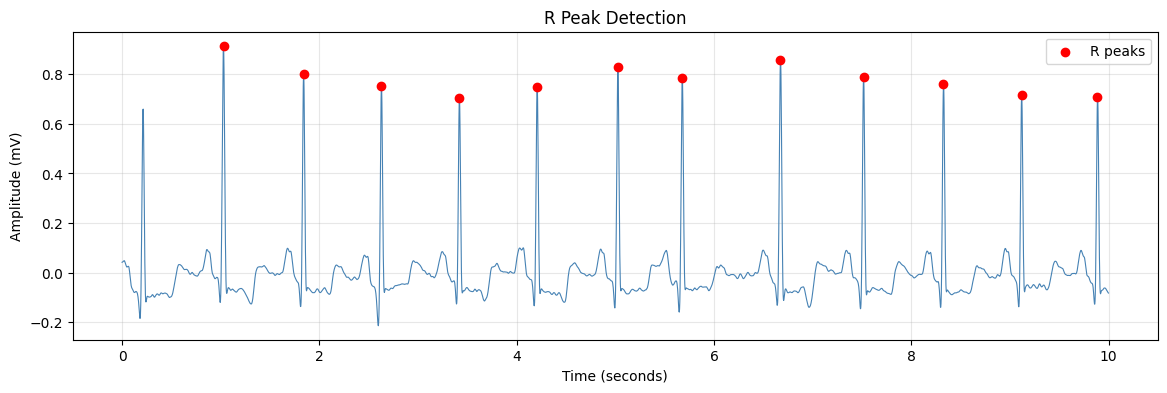

In [60]:
# detect R peaks in the cleaned signal
# neurokit2 uses multiple algorithms to find peaks reliably
peaks, info = nk.ecg_peaks(signal_clean, sampling_rate=fs)

# get the actual sample positions of each R peak
r_peaks = info['ECG_R_Peaks']

print(f'Total R peaks detected: {len(r_peaks)}')
print(f'Recording duration: {len(signal) / fs / 60:.1f} minutes')
print(f'Average heart rate: {len(r_peaks) / (len(signal) / fs) * 60:.1f} BPM')

# plot R peaks on the cleaned signal
seconds = 10
samples = seconds * fs
time = np.arange(samples) / fs

# find peaks within our 1 second window
peaks_in_window = r_peaks[r_peaks < samples]

plt.figure(figsize=(14, 4))
plt.plot(time, signal_clean[:samples], color='steelblue', linewidth=0.8)
plt.scatter(peaks_in_window / fs, signal_clean[peaks_in_window], color='red', zorder=5, label='R peaks')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.title('R Peak Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Average RR interval: 795.0 ms
Average heart rate: 75.5 BPM
HRV - Standard deviation of RR intervals (SDNN): 51.4 ms
Min RR interval: 522.2 ms
Max RR interval: 1666.7 ms


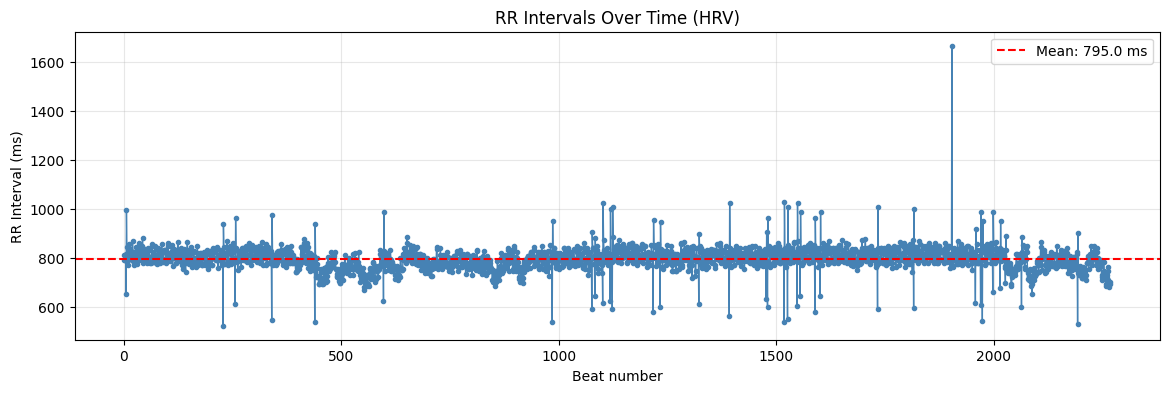

In [61]:
# calculate time between R peaks (RR intervals)
# this is measured in milliseconds
rr_intervals = np.diff(r_peaks) / fs * 1000 # convert to milliseconds

print(f'Average RR interval: {rr_intervals.mean():.1f} ms')
print(f'Average heart rate: {60000 / rr_intervals.mean():.1f} BPM')
print(f'HRV - Standard deviation of RR intervals (SDNN): {rr_intervals.std():.1f} ms')
print(f'Min RR interval: {rr_intervals.min():.1f} ms')
print(f'Max RR interval: {rr_intervals.max():.1f} ms')

# plot RR intervals over time
plt.figure(figsize=(14, 4))
plt.plot(rr_intervals, color='steelblue', linewidth=1, marker='o', markersize=3)
plt.axhline(rr_intervals.mean(), color='red', linestyle='--', label=f'Mean: {rr_intervals.mean():.1f} ms')
plt.xlabel('Beat number')
plt.ylabel('RR Interval (ms)')
plt.title('RR Intervals Over Time (HRV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
# load expert cardiologist annotations for record 100
annotation = wfdb.rdann('data/mit-bih-arrhythmia-database-1.0.0/100', 'atr')

# get annotation symbols and their positions
symbols = annotation.symbol
positions = annotation.sample

# count each type of beat
from collections import Counter
beat_counts = Counter(symbols)
print('Beat type counts:')
for symbol, count in beat_counts.most_common():
    print(f' {symbol}: {count}')

Beat type counts:
 N: 2239
 A: 33
 +: 1
 V: 1


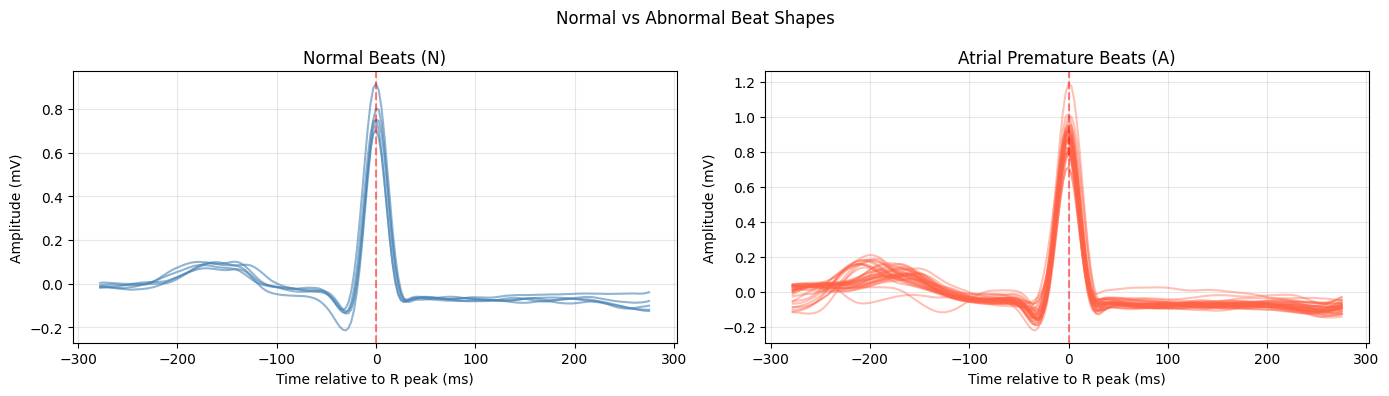

In [63]:
# Find positions of normal and atrial premature beats
normal_positions = positions[np.array(symbols) == 'N']
apb_positions = positions[np.array(symbols) == 'A']

# Extract a window of samples around each beat
window = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 5 normal beats overlaid - check boundaries
normal_plotted = 0
for pos in normal_positions:
    if pos-window >= 0 and pos+window < len(signal_clean):
        beat = signal_clean[pos-window:pos+window]
        time_window = np.arange(-window, window) / fs * 1000
        axes[0].plot(time_window, beat, alpha=0.6, color='steelblue')
        normal_plotted += 1
        if normal_plotted == 5:
            break

axes[0].set_title('Normal Beats (N)')
axes[0].set_xlabel('Time relative to R peak (ms)')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# Plot all atrial premature beats overlaid
for pos in apb_positions:
    if pos-window >= 0 and pos+window < len(signal_clean):
        beat = signal_clean[pos-window:pos+window]
        time_window = np.arange(-window, window) / fs * 1000
        axes[1].plot(time_window, beat, alpha=0.4, color='tomato')

axes[1].set_title('Atrial Premature Beats (A)')
axes[1].set_xlabel('Time relative to R peak (ms)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Normal vs Abnormal Beat Shapes')
plt.tight_layout()
plt.show()

In [64]:
# check what records are available
import os

data_dir = 'data/mit-bih-arrhythmia-database-1.0.0'

# Read the RECORDS file which lists all available recordings
with open(f'{data_dir}/RECORDS') as f:
    records = f.read().splitlines()

print(f'Total records available: {len(records)}')
print('First 10 records:', records[:10])

Total records available: 48
First 10 records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


In [65]:
# count beat types across all records
all_beats = Counter()

for rec in records:
    try:
        ann = wfdb.rdann(f'{data_dir}/{rec}', 'atr')
        all_beats.update(ann.symbol)
    except:
        pass

print('Beat distribution acroos entire dataset:')
for symbol, count in all_beats.most_common(10):
    print(f' {symbol}: {count}')

Beat distribution acroos entire dataset:
 N: 75052
 L: 8075
 R: 7259
 V: 7130
 /: 7028
 A: 2546
 +: 1291
 f: 982
 F: 803
 ~: 616
